In [1]:
# packages
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.tree import \
      (DecisionTreeRegressor as DTR, 
       DecisionTreeClassifier as DTC, 
       plot_tree)
from sklearn.ensemble import \
     (RandomForestRegressor as RFR,
      RandomForestClassifier as RFC,
      GradientBoostingRegressor as GBR)
from sklearn.model_selection import cross_val_score

# set seed
seed = 5498

### You'll need the heart attack data (heart.csv) to complete this exercise. Your goal is to predict the risk of having a heart attack (binary).

In [2]:
heart = pd.read_csv('data/heart.csv')
heart.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,UEX5427,40,Male,122,144/90,110,1,0,1,1,...,1.538008,252889,28.854477,318,6,7,Thailand,Asia,Northern Hemisphere,1
1,NBG3103,41,Male,357,174/73,109,0,1,1,1,...,7.030873,63196,37.387161,72,7,9,France,Europe,Northern Hemisphere,1
2,EIE1041,58,Male,206,107/105,63,0,0,1,0,...,8.086554,107870,20.299119,119,2,5,Colombia,South America,Northern Hemisphere,0
3,GYA0389,30,Male,142,132/107,86,1,0,1,0,...,5.039048,223985,30.717640,301,5,9,South Africa,Africa,Southern Hemisphere,0
4,IXT9616,69,Male,175,153/93,98,1,1,1,1,...,4.354972,24309,19.115698,675,7,7,Japan,Asia,Northern Hemisphere,0


In [3]:
heart.dtypes

Patient ID                          object
Age                                  int64
Sex                                 object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                object
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                             object
Continent  

In [5]:
heart.shape

(6572, 31)

### Feature engineering

In [6]:
def feature_engineering(df=heart):
    df['Male'] = (df.Sex == 'Male').astype(int)
    df['HealthyDiet'] = (df.Diet == 'Healthy').astype(int)
    df['UnhealthyDiet'] = (df.Diet == 'Unhealthy').astype(int)
    df[['BP1','BP2']] = df['Blood Pressure'].str.split('/', n=1, expand=True).astype(int)

feature_engineering()

In [7]:
heart.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Male,HealthyDiet,UnhealthyDiet,BP1,BP2
0,UEX5427,40,Male,122,144/90,110,1,0,1,1,...,7,Thailand,Asia,Northern Hemisphere,1,1,0,0,144,90
1,NBG3103,41,Male,357,174/73,109,0,1,1,1,...,9,France,Europe,Northern Hemisphere,1,1,1,0,174,73
2,EIE1041,58,Male,206,107/105,63,0,0,1,0,...,5,Colombia,South America,Northern Hemisphere,0,1,0,0,107,105
3,GYA0389,30,Male,142,132/107,86,1,0,1,0,...,9,South Africa,Africa,Southern Hemisphere,0,1,0,1,132,107
4,IXT9616,69,Male,175,153/93,98,1,1,1,1,...,7,Japan,Asia,Northern Hemisphere,0,1,0,1,153,93


In [8]:
indep_vars = ['Age', 'Male', 'Cholesterol', 'BP1', 'BP2', 'Heart Rate', 'Diabetes', 
              'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'HealthyDiet', 
              'UnhealthyDiet', 'Exercise Hours Per Week', 'Previous Heart Problems', 
              'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI',
              'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day']

X = heart[indep_vars]
y = heart['Heart Attack Risk']

In [9]:
X_train, X_test, y_train, y_test, Train, Test = train_test_split(X, y, heart, 
                                                                 random_state = seed, 
                                                                 test_size = 0.33, 
                                                                 shuffle = True)

### Univariate Analyses (Mean, Median, etc.)

In [10]:
Train.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Male,HealthyDiet,UnhealthyDiet,BP1,BP2
count,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,...,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000,4403.000000
mean,53.760164,261.571201,75.398592,0.656371,0.487168,0.895526,0.503066,0.599364,10.123129,0.506246,...,28.876482,418.384738,3.470815,7.045651,0.363389,0.703157,0.336589,0.334999,135.339768,85.200318
std,21.302684,81.111506,20.455754,0.474973,0.499892,0.305909,0.500047,0.490083,5.814093,0.500018,...,6.266748,222.756253,2.289825,1.986313,0.481030,0.456919,0.472597,0.472044,26.471761,14.656039
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004443,0.000000,...,18.009025,30.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000
25%,35.000000,194.000000,58.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.081525,0.000000,...,23.397345,229.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,112.500000,72.000000
50%,54.000000,261.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.266242,1.000000,...,28.768101,419.000000,3.000000,7.000000,0.000000,1.000000,0.000000,0.000000,135.000000,85.000000
75%,72.000000,333.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.292125,1.000000,...,34.269966,608.000000,5.000000,9.000000,1.000000,1.000000,1.000000,1.000000,159.000000,98.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,...,39.997211,800.000000,7.000000,10.000000,1.000000,1.000000,1.000000,1.000000,180.000000,110.000000


### Correlation Matrix

In [11]:
X_train.corr().style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,Age,Male,Cholesterol,BP1,BP2,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,HealthyDiet,UnhealthyDiet,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day
Age,1.000000,0.027272,-0.009153,0.008641,-0.002659,-0.003114,-0.017869,0.017139,0.398364,-0.008461,0.001217,-0.007662,0.010590,0.010047,-0.009670,0.006967,0.013658,0.024350,0.005220,-0.010506,0.014587,-0.009942,-0.016148
Male,0.027272,1.000000,0.016676,-0.006140,0.001995,-0.000366,0.000917,-0.000270,0.525688,0.000504,0.005447,0.006229,-0.004378,-0.009530,-0.011272,0.006828,-0.039140,-0.010779,0.007646,0.010282,0.015317,0.003985,-0.007092
Cholesterol,-0.009153,0.016676,1.000000,0.005745,-0.017203,-0.012507,-0.028839,-0.032771,0.026621,-0.015891,-0.022353,0.004833,-0.014249,0.016741,-0.022367,-0.001884,-0.034351,0.027106,-0.001468,0.012924,-0.014398,0.029993,-0.002332
BP1,0.008641,-0.006140,0.005745,1.000000,0.010701,0.022688,-0.012339,-0.015910,0.001102,0.000024,0.000444,-0.010324,-0.003148,0.003553,-0.022952,-0.000809,0.016166,0.016528,-0.002618,0.020022,0.014007,-0.017409,0.008220
BP2,-0.002659,0.001995,-0.017203,0.010701,1.000000,-0.011255,-0.007699,0.041776,-0.031407,-0.010003,-0.010521,0.014009,-0.005860,-0.014261,-0.003488,0.004126,0.002516,-0.007814,0.022487,0.007131,0.008308,0.001704,0.013755
Heart Rate,-0.003114,-0.000366,-0.012507,0.022688,-0.011255,1.000000,0.013984,-0.021304,-0.010406,0.017814,-0.000881,-0.017735,-0.020490,-0.003555,-0.023864,0.003857,-0.004242,-0.037228,0.017454,-0.017648,-0.003075,0.016770,0.016767
Diabetes,-0.017869,0.000917,-0.028839,-0.012339,-0.007699,0.013984,1.000000,-0.017140,-0.006363,0.021175,0.012529,0.014430,-0.026492,-0.006420,0.006648,0.013017,0.001319,0.004841,0.009121,-0.015689,0.006697,0.013022,0.004351
Family History,0.017139,-0.000270,-0.032771,-0.015910,0.041776,-0.021304,-0.017140,1.000000,0.000144,-0.002796,0.000338,-0.001907,0.015815,-0.021142,-0.003542,-0.010742,0.015665,0.009992,0.008011,-0.023486,-0.016172,0.009348,-0.016454
Smoking,0.398364,0.525688,0.026621,0.001102,-0.031407,-0.010406,-0.006363,0.000144,1.000000,0.009520,0.016225,-0.000266,-0.007709,-0.006519,-0.018010,-0.002338,-0.022788,0.014017,0.007357,0.011295,0.033460,0.000835,-0.023927
Obesity,-0.008461,0.000504,-0.015891,0.000024,-0.010003,0.017814,0.021175,-0.002796,0.009520,1.000000,-0.035773,0.000438,-0.010608,0.012616,0.032404,-0.004300,-0.005804,0.000109,-0.003053,-0.011320,0.015713,0.016892,0.001803


### To predict heart attack risk, we'll start by building a few simple decision trees.

In [12]:
tree1 = DTC(max_depth=1)
tree1.fit(X_train, y_train)

tree2 = DTC(max_depth=2)
tree2.fit(X_train, y_train)

tree3 = DTC(max_depth=3)
tree3.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### We can draw plots of each of these decision trees

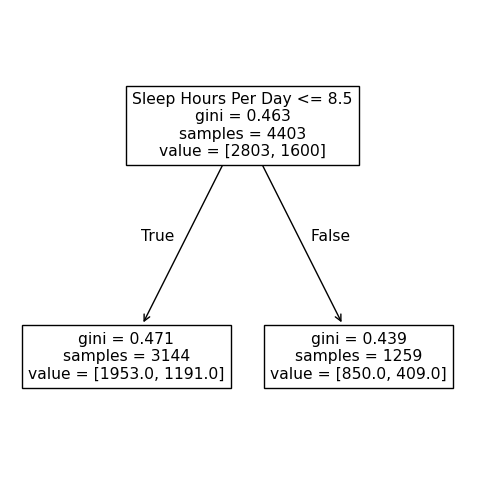

In [13]:
feature_names = list(X_train.columns)
ax = subplots(figsize=(6,6))[1]
plot_tree(tree1,
          feature_names=feature_names,
          ax=ax);

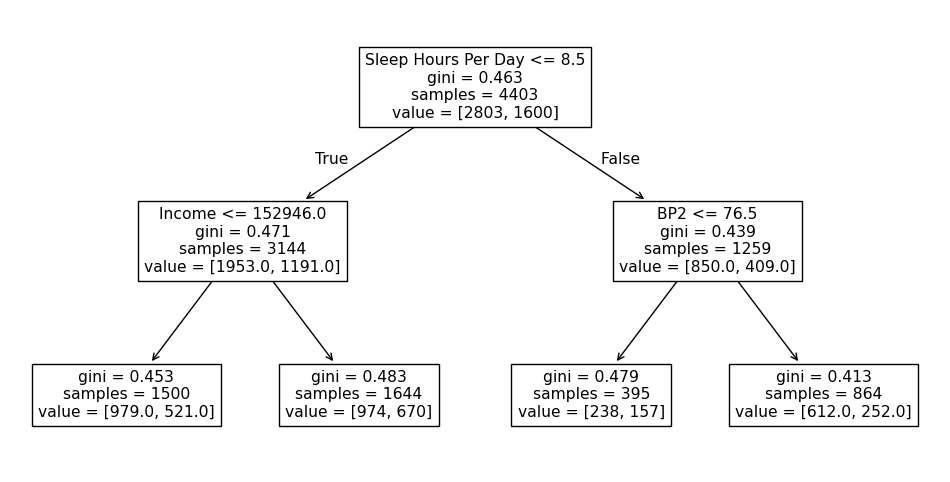

In [14]:
ax = subplots(figsize=(12,6))[1]
plot_tree(tree2,
          feature_names=feature_names,
          ax=ax);

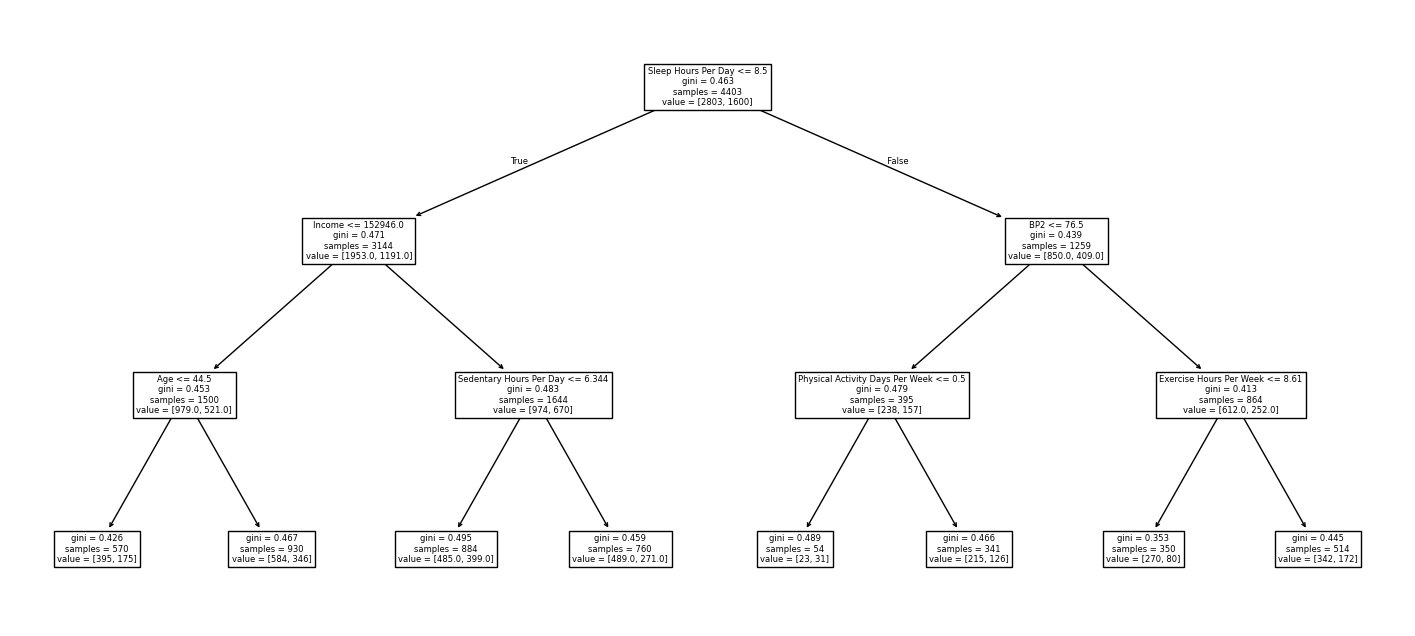

In [15]:
ax = subplots(figsize=(18,8))[1]
plot_tree(tree3,
          feature_names=feature_names,
          ax=ax);

### Create a new tree with depth 3 that requires there to be at least 100 records in each leaf.

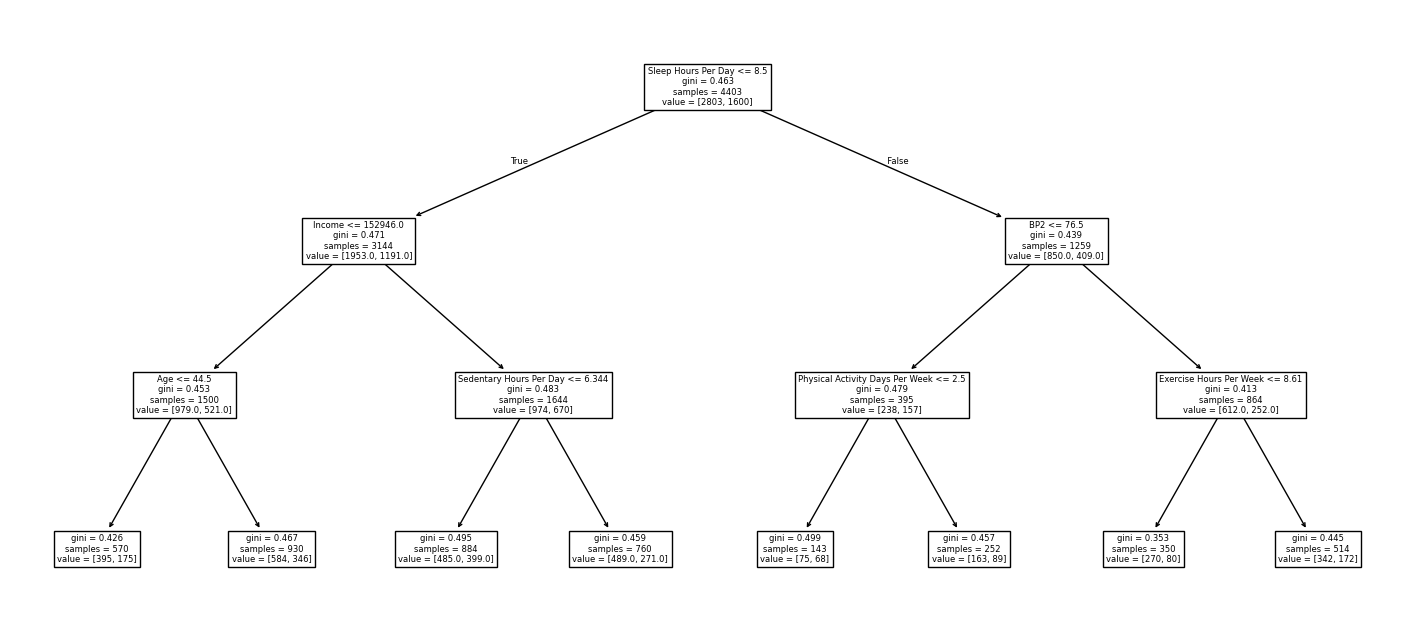

In [16]:
tree4 = DTC(max_depth=3, min_samples_leaf=100, random_state=seed)
tree4.fit(X_train, y_train)

ax = subplots(figsize=(18,8))[1]
plot_tree(tree4,
          feature_names=feature_names,
          ax=ax);

### Create a new version of the last tree so that it limits the number of leaf nodes to 8 rather than limiting the depth to 3.

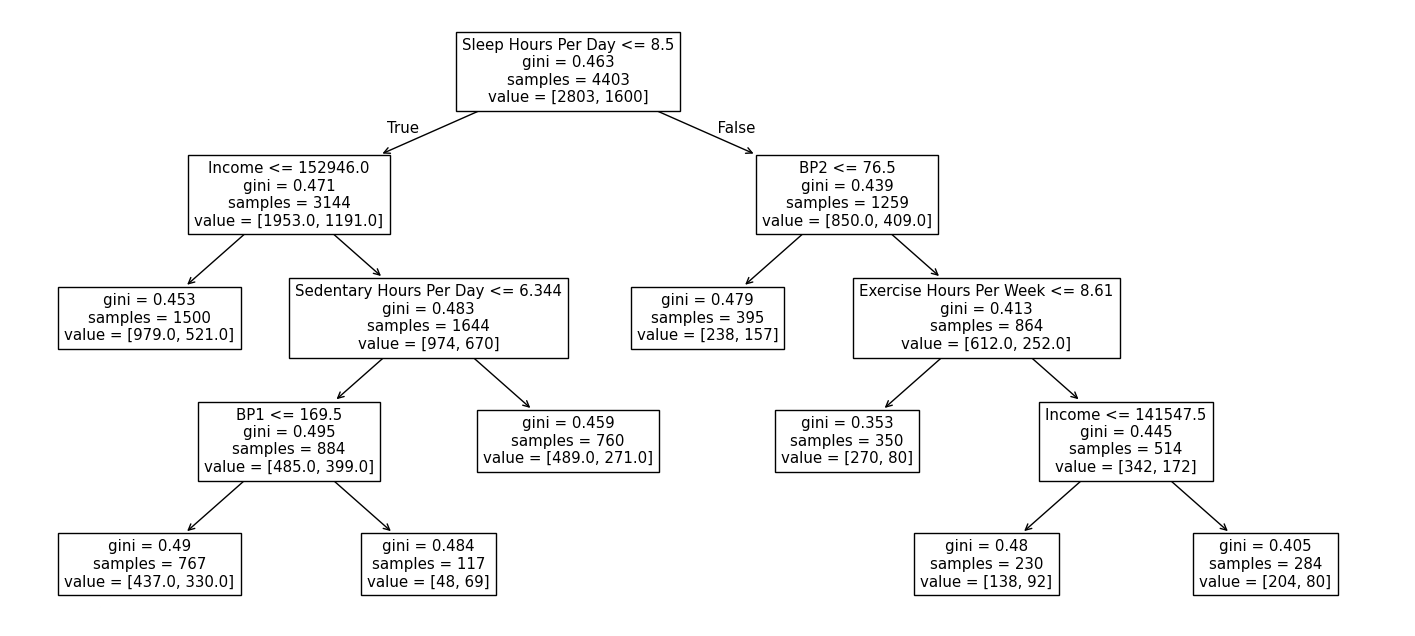

In [17]:
tree5 = DTC(max_leaf_nodes=8, min_samples_leaf=100, random_state=seed)
tree5.fit(X_train, y_train)

ax = subplots(figsize=(18,8))[1]
plot_tree(tree5,
          feature_names=feature_names,
          ax=ax);

### Create a basic random forest model on the training set.

In [18]:
rf_basic = RFC(max_features=len(indep_vars),
               criterion='log_loss',
               n_estimators=50,
               max_depth=10,
               min_samples_leaf=1,
               bootstrap=True,
               oob_score=True,
               random_state=seed)
rf_basic.fit(X_train, y_train)

,n_estimators,50
,criterion,'log_loss'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,23
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


### We'll use this function to quickly calculate the log loss of a model.

In [19]:
def log_loss(y_true, y_prob, eps=1e-15):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # avoid log(0)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    ll = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return ll

### Compute the log loss on the training set.

In [20]:
y_hat_basic_train = rf_basic.predict_proba(X_train)[:,1]
print('train log loss:', log_loss(y_train, y_hat_basic_train))

train log loss: 0.4683745231235701


### Calculate the out-of-bag error (bootstrapping) on training data to estimate the log loss on the test set.

In [21]:
y_hat_basic_oob = rf_basic.oob_decision_function_[:,1]
print('oob log loss:  ', log_loss(y_train, y_hat_basic_oob))

oob log loss:   0.6667260171612608


### Compute the log loss on the test set.

In [22]:
y_hat_basic_test = rf_basic.predict_proba(X_test)[:,1]
print('test log loss: ', log_loss(y_test, y_hat_basic_test))

test log loss:  0.6574443298870886


### Build an improved random forest model on this same set of data. 

You will be scored according to how well it performs on an unseen holdout set.

In [23]:
# Documentation: https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestRegressor.html

rf_better = RFC(
    max_features='sqrt',
    criterion='log_loss',
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    bootstrap=True,
    oob_score=True,
    random_state=seed
)
rf_better.fit(X_train, y_train)

,n_estimators,300
,criterion,'log_loss'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


### Calculate the out-of-bag log loss for this model. Store it as `log_loss_oob`

In [24]:
y_hat_better_oob = rf_better.oob_decision_function_[:,1]

log_loss_oob = log_loss(y_train, y_hat_better_oob)
print(log_loss_oob)

0.6565973467024008


### Create the feature importance list for this model.

In [25]:
feature_imp = pd.DataFrame(
    {'importance':rf_better.feature_importances_},
    index=indep_vars)
feature_imp

,importance
Age,0.070340
Male,0.008569
Cholesterol,0.077943
BP1,0.072191
BP2,0.062025
Heart Rate,0.065952
Diabetes,0.008926
Family History,0.007624
Smoking,0.004397
Obesity,0.010588


### Sort the importance values and then create a horizontal bar chart that displays the sorted variable importances.

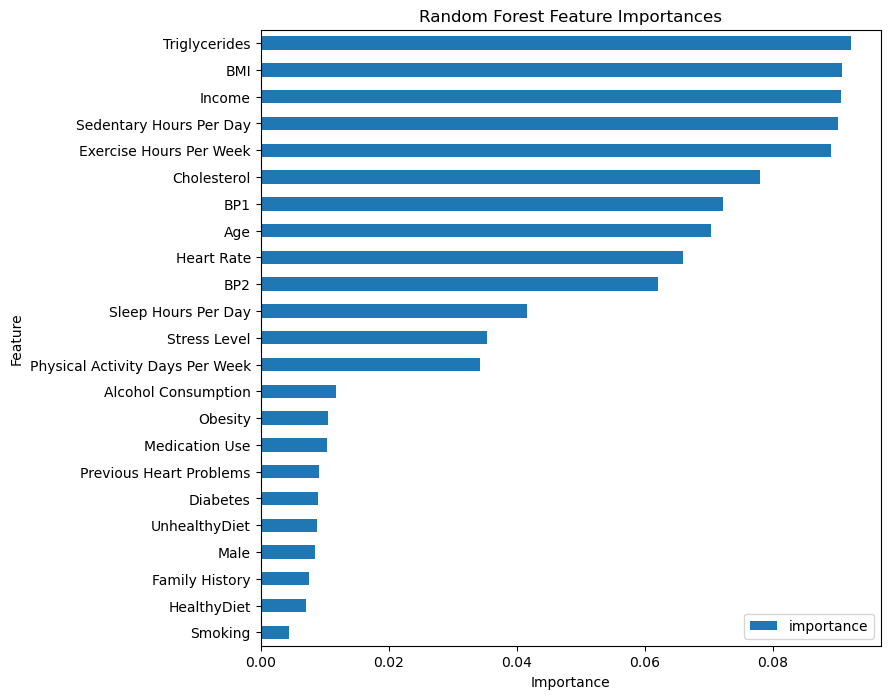

In [26]:
feature_imp_sorted = feature_imp.sort_values(by='importance')

feature_imp_sorted.plot.barh(figsize=(8,8))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.show()

## Discussion Questions

### (1) Explain what "value" means in the decision tree plots.

In the decision tree plots, value shows the number of training observations from each class that fall into that node.

### (2) How is “log loss” different from the log likelihood we defined in class?

Log loss is the average prediction error for probabilistic classification, while log likelihood is the total likelihood of the observed data under a model. It's basically the negative average log likelihood per observation.

### (3) Explain how we know the basic model is overfit before attempting to build any other models.

We know the basic model is overfit because it performs much better on the training data than on the out-of-bag and test data. That gap shows it is learning the training set too closely instead of generalizing well.